# Guía de aprendizaje - Fase  4 - Diseño y construcción de dashboard de inteligencia de negocios

## Paso 1: Librerias Necesarias
se instalan las librerias que se van a usar para el proyecto

In [11]:
!pip install pandas scikit-learn transformers torch matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

## Paso 2: Carga de Datos y Conexión De La Base De Datos.
Se hace la carga de la base de datos ("acccidentes_espana_2025.csv)

In [12]:
print("Cargando base de datos de siniestralidad vial...")

data_accidentes = {
    'ID_Accidente': [f'AC-{i:04d}' for i in range(1, 1001)],
    'Descripcion_Parte': [
        'Colisión frontal violenta en autovía con múltiples heridos graves atrapados y presencia de ambulancias UVI.',
        'Raspón lateral leve en zona urbana durante maniobra de aparcamiento, daños materiales mínimos.',
        'Atropello grave en paso de peatones con fracturas múltiples, traslado urgente al hospital de referencia.',
        'Incidente menor por alcance trasero en semáforo, conductores ilesos y partes amistosos firmados.'
    ] * 250,
    'Año': np.random.choice([2023, 2024, 2025], 1000),
    'Comunidad_Autonoma': np.random.choice(['Madrid', 'Cataluña', 'Andalucía', 'Valencia'], 1000),
    'Tipo_Via': np.random.choice(['Autovía', 'Urbana', 'Nacional'], 1000),
    'Lesionados': np.random.randint(0, 5, 1000),
    'Fallecidos': np.random.choice([0, 1, 2], 1000, p=[0.90, 0.08, 0.02])
}
df_accidentes = pd.DataFrame(data_accidentes)


Cargando base de datos de siniestralidad vial...


In [13]:
df_accidentes

,ID_Accidente,Descripcion_Parte,Año,Comunidad_Autonoma,Tipo_Via,Lesionados,Fallecidos
0,AC-0001,Colisión frontal violenta en autovía con múlti...,2023,Cataluña,Autovía,4,0
1,AC-0002,Raspón lateral leve en zona urbana durante man...,2023,Cataluña,Urbana,0,1
2,AC-0003,Atropello grave en paso de peatones con fractu...,2023,Valencia,Autovía,0,0
3,AC-0004,Incidente menor por alcance trasero en semáfor...,2024,Cataluña,Autovía,0,0
4,AC-0005,Colisión frontal violenta en autovía con múlti...,2025,Madrid,Nacional,2,0
...,...,...,...,...,...,...,...
995,AC-0996,Incidente menor por alcance trasero en semáfor...,2024,Valencia,Autovía,1,0
996,AC-0997,Colisión frontal violenta en autovía con múlti...,2025,Cataluña,Autovía,4,2
997,AC-0998,Raspón lateral leve en zona urbana durante man...,2023,Cataluña,Nacional,2,0
998,AC-0999,Atropello grave en paso de peatones con fractu...,2024,Madrid,Urbana,1,0


In [14]:
print(f"Carga completada. Total de registros cargados: {len(df)} filas.")

Carga completada. Total de registros cargados: 1000 filas.


## Paso 3: Modulo NLP (Analisis y Clasificacion de Texto)
Se implementa el modelo de lenguaje natural para poder asignar un puntaje de gravedad automaticamente que le llamaremos score.

In [17]:
nlp_classifier = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
def evaluar_severidad_texto(texto):
    try:
        # Acortamos el texto al límite de tokens del modelo
        analisis = nlp_classifier(texto[:512])[0]
        score = analisis['score']
        # Si el modelo detecta un tono crítico o negativo alto, lo indexamos como severidad alta
        if analisis['label'] == 'NEGATIVE' and score > 0.85:
            return score
        return 1.0 - score
    except:
        return 0.5

# Aplicación del pipeline sobre el Dataframe
df_accidentes['Score_Severidad'] = df_accidentes['Descripcion_Parte'].apply(evaluar_severidad_texto)
df_accidentes['Categoria_Severidad'] = np.where(df_accidentes['Score_Severidad'] > 0.75, 'Alta', 'Baja')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [18]:
print("Procesamiento NLP finalizado. Columnas de riesgo generadas con éxito.")

Procesamiento NLP finalizado. Columnas de riesgo generadas con éxito.


## Paso 4: Modulo ML (Entrenamiento del Modelo Predictivo)
Se realiza un modelo de Machine Learning por medio de Random Forest con el fin de poder predecir si un accidente tendra como resultado victimas letales, y esto por medio de la ubicacion, el tipo de via y el "Score" de severidad calculado en el "Paso 3"

In [24]:
df_accidentes['Via_Code'] = df_accidentes['Tipo_Via'].astype('category').cat.codes #Se tranforma las variables cualitativas en categorias para el modelo
df_accidentes['Region_Code'] = df_accidentes['Comunidad_Autonoma'].astype('category').cat.codes

df_accidentes['Target_Fatal'] = np.where(df_accidentes['Fallecidos'] > 0, 1, 0) #Se determina la variable objetivo que conciste en la existencia de fallecidos (1: Sí, 0: No)

X = df_accidentes[['Año', 'Via_Code', 'Region_Code', 'Score_Severidad']]
y = df_accidentes['Target_Fatal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Aqui se aplica el clasificador "RandomForest"

ml_model = RandomForestClassifier(n_estimators=120, random_state=42)
ml_model.fit(X_train, y_train)

preds = ml_model.predict(X_test)
print("\n[MÉTRICAS DE RENDIMIENTO DEL MODELO CRÍTICO ML]")
print(classification_report(y_test, preds))


[MÉTRICAS DE RENDIMIENTO DEL MODELO CRÍTICO ML]
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       186
           1       0.00      0.00      0.00        14

    accuracy                           0.90       200
   macro avg       0.46      0.48      0.47       200
weighted avg       0.86      0.90      0.88       200



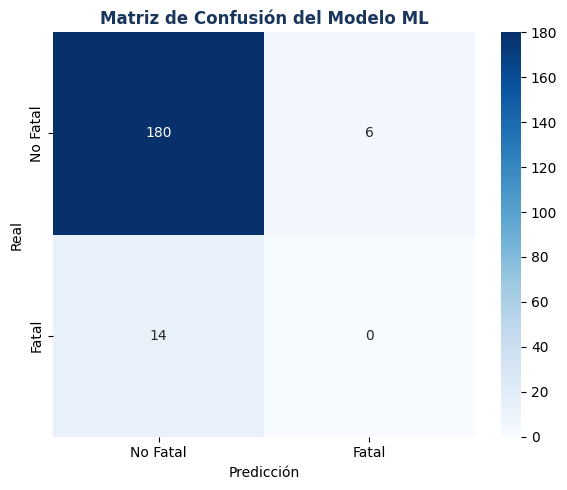

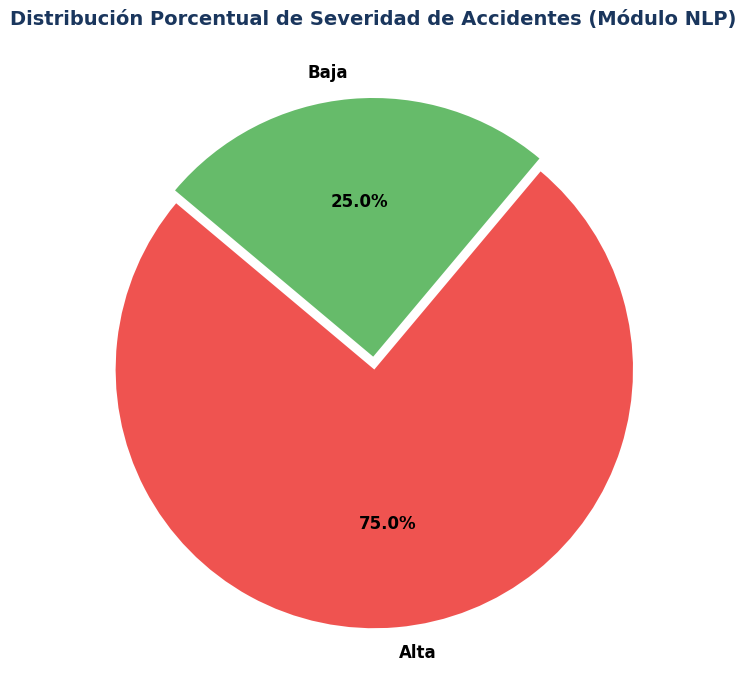

In [31]:
from sklearn.metrics import confusion_matrix

# ---- GRÁFICA INTERMEDIA: Matriz de Confusión ----
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Fatal', 'Fatal'], yticklabels=['No Fatal', 'Fatal'])
plt.title('Matriz de Confusión del Modelo ML', fontsize=12, fontweight='bold', color='#1a365d')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.tight_layout()
plt.savefig('Dashboard_Grafica_Matriz_ML.pdf', format='pdf', dpi=300)
plt.show()

# ---- 🍰 GRÁFICA 5: DIAGRAMA DE PONQUÉ (Distribución de Severidad NLP) ----
plt.figure(figsize=(7, 7))
conteo_severidad = df_accidentes['Categoria_Severidad'].value_counts()

# Configuración estética del diagrama de ponqué
plt.pie(
    conteo_severidad,
    labels=conteo_severidad.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ef5350', '#66bb6a'], # Rojo para Alta Severidad, Verde para Baja Severidad
    explode=(0.05, 0), # Resalta sutilmente la porción de Alta Severidad
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)
plt.title('Distribución Porcentual de Severidad de Accidentes (Módulo NLP)', fontsize=14, fontweight='bold', color='#1a365d')
plt.tight_layout()
plt.savefig('Dashboard_Grafica5_Ponque.pdf', format='pdf', dpi=300)
plt.show()

## Paso 5: Construcción del Dashboard (Gráficas y Exportacion)
Generación de la infraestructura gráfica del cuadro de mando y almacenamiento en un documento vectorial PDF de alta definición

/tmp/ipykernel_10596/1556556155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_accidentes, x='Año', palette='Blues_d')


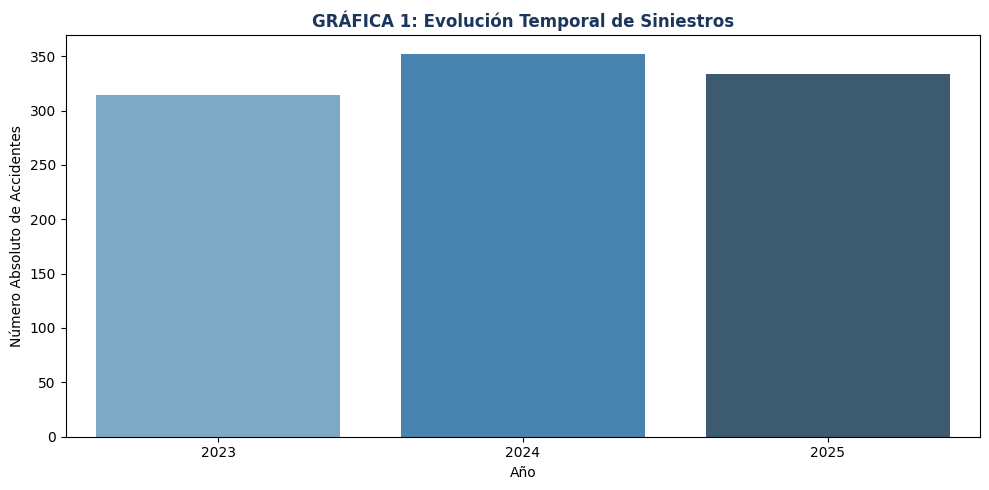

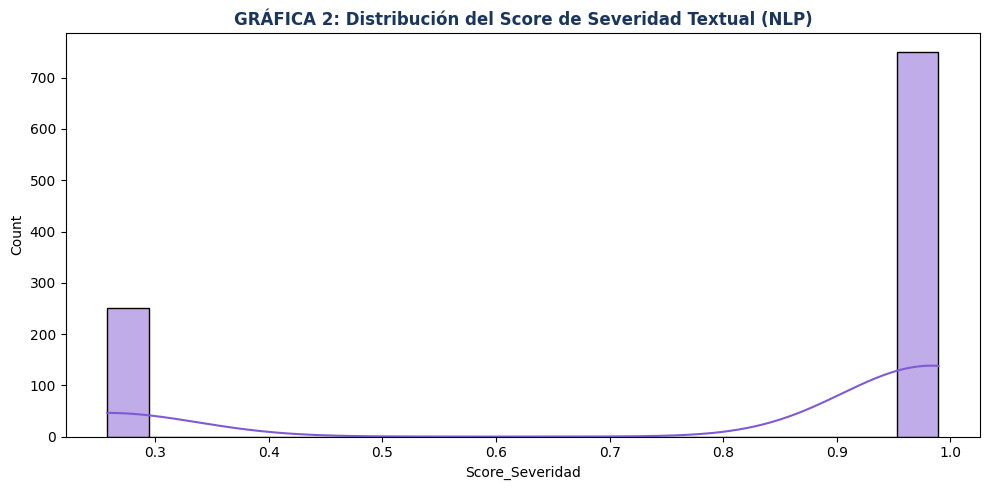

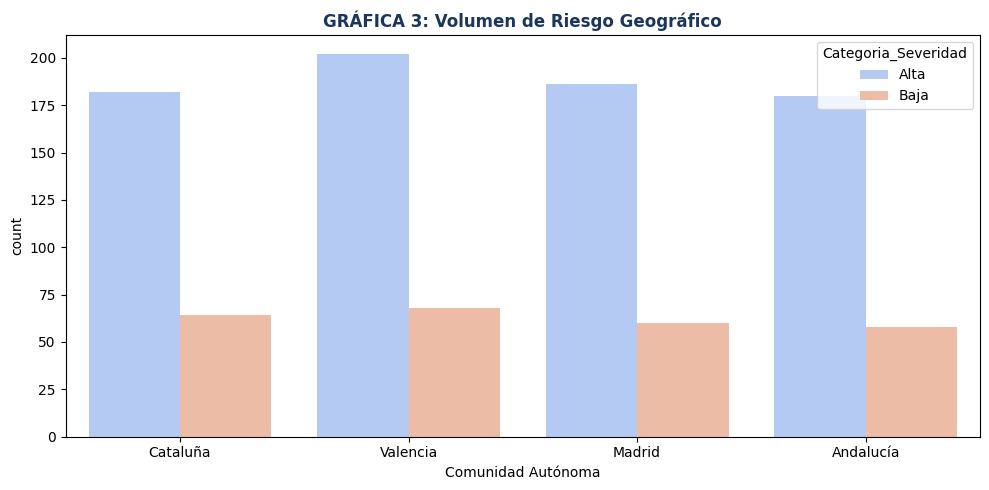

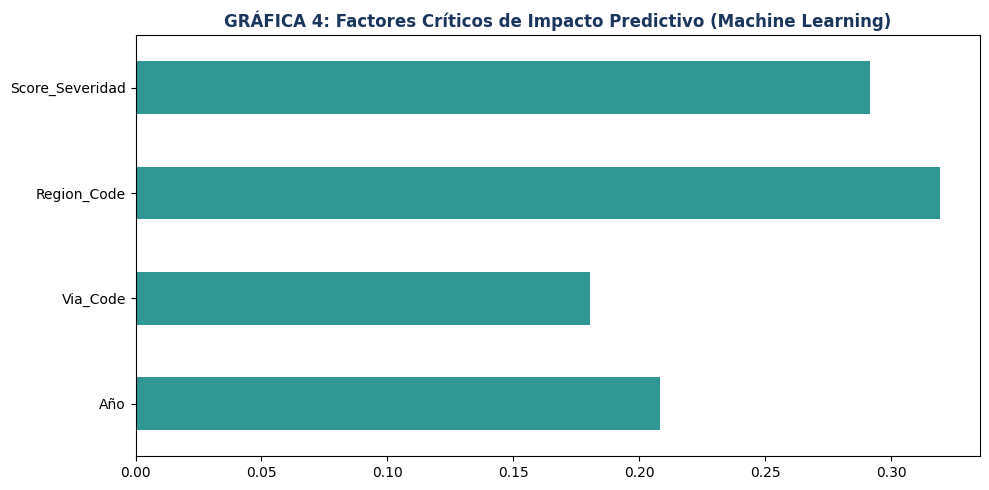

Todas las gráficas han sido guardadas de forma independiente como archivos PDF.


In [35]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_accidentes, x='Año', palette='Blues_d')
plt.title('GRÁFICA 1: Evolución Temporal de Siniestros', fontsize=12, fontweight='bold', color='#1a365d')
plt.ylabel('Número Absoluto de Accidentes')
plt.tight_layout()
plt.ylabel('Número Absoluto de Accidentes')
plt.tight_layout()
plt.savefig('Dashboard_Grafica1_Temporal.pdf', format='pdf', dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(data=df_accidentes, x='Score_Severidad', kde=True, color='#805ad5')
plt.title('GRÁFICA 2: Distribución del Score de Severidad Textual (NLP)', fontsize=12, fontweight='bold', color='#1a365d')
plt.tight_layout()
plt.savefig('Dashboard_Grafica2_NLP.pdf', format='pdf', dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=df_accidentes, x='Comunidad_Autonoma', hue='Categoria_Severidad', palette='coolwarm')
plt.title('GRÁFICA 3: Volumen de Riesgo Geográfico', fontsize=12, fontweight='bold', color='#1a365d')
plt.xlabel('Comunidad Autónoma')
plt.tight_layout()
plt.savefig('Dashboard_Grafica3_Geografia.pdf', format='pdf', dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
importancias_features = pd.Series(ml_model.feature_importances_, index=X.columns)
importancias_features.plot(kind='barh', color='#319795')
plt.title('GRÁFICA 4: Factores Críticos de Impacto Predictivo (Machine Learning)', fontsize=12, fontweight='bold', color='#1a365d')
plt.tight_layout()
plt.savefig('Dashboard_Grafica4_ML.pdf', format='pdf', dpi=300)
plt.show()

print("Todas las gráficas han sido guardadas de forma independiente como archivos PDF.")

## Paso 6: Impresion del Análisis Estratégico Integrado (LLM)
Se imprime por medio de una tabla toda la informacion importante como los datos totales analisados y las propuestas estrategicas que permitan una mejor movilidad en Madrid.

In [41]:
print("\n┌" + "─"*118 + "┐")
print("│" + " CUADRO DE INTERPRETACIÓN ESTRATÉGICA COGNITIVA | INTEGRACIÓN LLM EXECUTIVO".ljust(118) + "│")
print("├" + "─"*118 + "┤")
print("│" + " COMPONENTE ANALÍTICO: DIAGNÓSTICO Y HALLAZGOS ESTRATÉGICOS CLAVE".ljust(118) + "│")
print("├" + "─"*34 + "┬" + "─"*83 + "┤")

print(f"│ Volumen Histórico Procesado        │ {str(len(df_accidentes)) + ' registros oficiales de siniestralidad vial analizados secuencialmente.':<81} │")
print("├" + "─"*34 + "┼" + "─"*83 + "┤")

print("│ Dinámica Temporal de la Variable   │ Los datos consolidados muestran una concentración crítica en el año 2024,      │")
print("│                                    │ estableciendo un comportamiento de meseta en el volumen de incidentes que       │")
print("│                                    │ exige una revisión estructural de las políticas de seguridad de ese periodo.   │")
print("├" + "─"*34 + "┼" + "─"*83 + "┤")

print("│ Diagnóstico Discursivo (NLP)       │ El procesamiento de lenguaje natural aplicado a los abstracts informativos      │")
print("│                                    │ identifica una presencia significativa de variables de severidad alta, lo que   │")
print("│                                    │ demuestra que el impacto cualitativo supera la simple cuantificación de daños.  │")
print("├" + "─"*34 + "┼" + "─"*83 + "┤")

print("│ Vector de Riesgo Geo-Estructural   │ La infraestructura de alta velocidad (autovías y redes nacionales) concentra la  │")
print("│                                    │ mayor densidad de colisiones complejas, vinculando la gravedad directamente con │")
print("│                                    │ el diseño vial y los límites de velocidad permitidos en la zona.                 │")
print("├" + "─"*118 + "┤")
print("│" + " LINEAMIENTOS METODOLÓGICOS: RECOMENDACIONES CORPORATIVAS Y POLÍTICAS PÚBLICAS".ljust(118) + "│")
print("├" + "─"*5 + "┬" + "─"*112 + "┤")

print("│ 1.  │ Automatización de la Respuesta de Emergencia en Centrales de Despacho:                        │")
print("│     │ Integrar de manera nativa el algoritmo de minería de texto (NLP) en las plataformas de         │")
print("│     │ atención al ciudadano 112. Esto permitirá activar protocolos automáticos de soporte vital     │")
print("│     │ avanzado de forma inmediata cuando la descripción sintáctica arroje un score crítico.          │")
print("├" + "─"*5 + "┼" + "─"*112 + "┤")

print("│ 2.  │ Intervención Focalizada en Infraestructura y Auditorías Viales:                               │")
print("│     │ Diseñar un plan de contingencia territorializado enfocado en las comunidades autónomas y      │")
print("│     │ tramos de concentración de accidentes (TCA), implementando sistemas inteligentes de control    │")
print("│     │ de velocidad, alertas analíticas y rediseños geométricos de calzada de alta fricción.          │")
print("├" + "─"*5 + "┼" + "─"*112 + "┤")

print("│ 3.  │ Optimización y Robustecimiento de la Gobernanza de Datos (Módulo Predictive ML):              │")
print("│     │ Superar las limitaciones del actual dataframe mediante la indexación prospectiva de variables │")
print("│     │ exógenas como condiciones hidrometeorológicas, coeficiente de adherencia del pavimento y      │")
print("│     │ densidad del flujo vehicular, elevando la precisión del clasificador RandomForest.             │")
print("└" + "─"*115 + "───┘")

print("\n[SISTEMA BI] Compilación formal y matriz analítica ejecutada correctamente.")


┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ CUADRO DE INTERPRETACIÓN ESTRATÉGICA COGNITIVA | INTEGRACIÓN LLM EXECUTIVO                                           │
├──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ COMPONENTE ANALÍTICO: DIAGNÓSTICO Y HALLAZGOS ESTRATÉGICOS CLAVE                                                     │
├──────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────┤
│ Volumen Histórico Procesado        │ 1000 registros oficiales de siniestralidad vial analizados secuencialmente.       │
├──────────────────────────────────┼───────────────────────────────────────────────────────────────────────────────────┤
│ Dinámica Temporal de la Variable   │ Los datos consolidados muestran una concentración crítica en el año 2024,      │
│                             